# Fuzzy POI Recommendation System for Trip Planning

This notebook implements a local Fuzzy Expert System for recommending points of interest (POIs) in a trip-planning workflow. It loads attractions and restaurants from JSON files, normalizes them into one POI table, filters by city, generates fuzzy input features directly from the available data, applies a Mamdani fuzzy control system, and ranks the best places to visit.

The implementation uses `scikit-fuzzy` for the expert system and keeps the project fully local. It does not use APIs, route optimization, or machine learning models.

## 1. Install and Import Dependencies

The first code cell checks whether the required packages are available and installs any missing packages into the active notebook environment. If your course or environment manages packages separately, set `AUTO_INSTALL_DEPENDENCIES = False`.

In [1]:
AUTO_INSTALL_DEPENDENCIES = True

import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scikit-fuzzy": "skfuzzy",
    "ipywidgets": "ipywidgets",
}

missing_packages = [
    package_name
    for package_name, import_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages and AUTO_INSTALL_DEPENDENCIES:
    print("Installing missing packages:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])
elif missing_packages:
    print("Missing packages:", ", ".join(missing_packages))
    print("Install them with: %pip install numpy pandas matplotlib scikit-fuzzy ipywidgets")

import json
import math
import re
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from IPython.display import Markdown, clear_output, display
from skfuzzy import control as ctrl

try:
    import ipywidgets as widgets
except Exception as widget_error:
    widgets = None
    print("ipywidgets is unavailable. The non-interactive pipeline will still run.")
    print(widget_error)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")

## 2. Data Path Configuration

Configure all data paths and user preferences in this cell. The string `PROJECT_ROOT` is treated as a placeholder and is automatically resolved to the repository root when the notebook runs.

In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == "fuzzy" and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if (candidate / "data").exists():
            PROJECT_ROOT = candidate
            break

ATTRACTIONS_PATH = "PROJECT_ROOT/data/raw/las_vegas/attractions.json"
RESTAURANTS_PATH = "PROJECT_ROOT/data/raw/las_vegas/restaurants.json"

CITY_NAME = "Las Vegas"

# Optional user/hotel location.
# If HOTEL_LAT and HOTEL_LON are None, estimate city center from the average coordinates of filtered POIs.
HOTEL_LAT = None
HOTEL_LON = None

USER_BUDGET_LEVEL = "medium"  # options: "low", "medium", "high", "luxury"
USER_INTERESTS = ["Nature & Parks", "Sights & Landmarks", "Museums", "American", "Italian"]
PREFERRED_DAY_INDEX = 2       # 0=Sunday, 1=Monday, ..., 6=Saturday
PREFERRED_VISIT_TIME = 14 * 60  # minutes after midnight, example 14:00
TOP_N = 10

print("Resolved project root:", PROJECT_ROOT)

Resolved project root: D:\Projects\tripsage-langchain-pipeline


## 3. Helper Functions

These helpers keep the pipeline robust to missing, malformed, or nested JSON fields. They handle safe numeric parsing, city extraction, category text construction, price interpretation, opening-hour checks, and distance calculations.

In [3]:
BUDGET_LEVELS = {
    "low": 1,
    "medium": 2,
    "high": 3,
    "luxury": 4,
}

DAY_OPTIONS = [
    ("Sunday", 0),
    ("Monday", 1),
    ("Tuesday", 2),
    ("Wednesday", 3),
    ("Thursday", 4),
    ("Friday", 5),
    ("Saturday", 6),
]

RANKED_DISPLAY_COLUMNS = [
    "rank",
    "name",
    "source_type",
    "city",
    "rating",
    "num_reviews",
    "distance_km",
    "rating_score",
    "popularity_score",
    "budget_match",
    "interest_match",
    "availability_score",
    "recommendation_score",
    "visit_priority",
    "category_text",
]


def resolve_data_path(path: str | Path) -> Path:
    path_text = str(path)
    if path_text.startswith("PROJECT_ROOT"):
        path_text = path_text.replace("PROJECT_ROOT", str(PROJECT_ROOT), 1)
    return Path(path_text).expanduser().resolve()


def is_missing(value: Any) -> bool:
    if value is None:
        return True
    if isinstance(value, (list, tuple, dict, set)):
        return False
    try:
        return bool(pd.isna(value))
    except Exception:
        return False


def safe_text(value: Any, default: str = "") -> str:
    if is_missing(value):
        return default
    return str(value).strip()


def safe_float(value: Any, default: float | None = None) -> float | None:
    if is_missing(value):
        return default
    if isinstance(value, bool):
        return float(value)
    if isinstance(value, (int, float, np.integer, np.floating)):
        if math.isfinite(float(value)):
            return float(value)
        return default

    text = str(value).strip()
    if not text or text.lower() in {"none", "nan", "null", "n/a", "na", "unknown"}:
        return default

    text = text.replace(",", "")
    match = re.search(r"-?\d+(?:\.\d+)?", text)
    if not match:
        return default
    try:
        return float(match.group(0))
    except ValueError:
        return default


def safe_int(value: Any, default: int = 0) -> int:
    parsed = safe_float(value, default=None)
    if parsed is None:
        return default
    return int(round(parsed))


def load_json(path: str | Path) -> list[dict]:
    resolved_path = resolve_data_path(path)
    if not resolved_path.exists():
        raise FileNotFoundError(f"Could not find JSON file: {resolved_path}")

    with resolved_path.open("r", encoding="utf-8") as file:
        data = json.load(file)

    if isinstance(data, list):
        return data

    if isinstance(data, dict):
        for key in ("data", "results", "items", "attractions", "restaurants"):
            if isinstance(data.get(key), list):
                return data[key]
        return [data]

    raise ValueError(f"Expected a list or dict in {resolved_path}, got {type(data).__name__}")


def collect_names(value: Any) -> list[str]:
    names = []
    if is_missing(value):
        return names

    if isinstance(value, dict):
        for key in ("name", "title", "key", "tag_text", "primary_category"):
            text = safe_text(value.get(key))
            if text:
                names.append(text)
        return names

    if isinstance(value, list):
        for entry in value:
            names.extend(collect_names(entry))
        return names

    text = safe_text(value)
    if text:
        names.append(text)
    return names


def dedupe_keep_order(values: list[str]) -> list[str]:
    seen = set()
    result = []
    for value in values:
        normalized = value.casefold()
        if normalized and normalized not in seen:
            result.append(value)
            seen.add(normalized)
    return result


def extract_city(item: dict) -> str:
    address_obj = item.get("address_obj") if isinstance(item.get("address_obj"), dict) else {}
    candidates = [
        address_obj.get("city"),
        item.get("parent_display_name"),
        item.get("ranking_geo"),
    ]

    location_string = safe_text(item.get("location_string"))
    if location_string:
        candidates.append(location_string.split(",")[0].strip())

    ancestors = item.get("ancestors")
    if isinstance(ancestors, list):
        for ancestor in ancestors:
            if not isinstance(ancestor, dict):
                continue
            subcategories = ancestor.get("subcategory", [])
            if any(isinstance(sub, dict) and sub.get("key") == "city" for sub in subcategories):
                candidates.append(ancestor.get("name"))

    for candidate in candidates:
        text = safe_text(candidate)
        if text:
            return text
    return ""


def extract_category_text(item: dict) -> str:
    fields = [
        item.get("category"),
        item.get("subcategory"),
        item.get("subtype"),
        item.get("cuisine"),
        item.get("dietary_restrictions"),
        item.get("establishment_types"),
        item.get("location_subtype"),
        item.get("ranking_category"),
        item.get("ranking_subcategory"),
    ]

    names = []
    for field in fields:
        names.extend(collect_names(field))

    return " | ".join(dedupe_keep_order(names))


def extract_price_value(item: dict) -> float | None:
    direct_candidates = [
        item.get("price"),
        item.get("price_level"),
    ]

    offer_group = item.get("offer_group") if isinstance(item.get("offer_group"), dict) else {}
    direct_candidates.append(offer_group.get("lowest_price"))

    offer_list = offer_group.get("offer_list", [])
    if isinstance(offer_list, list):
        for offer in offer_list:
            if isinstance(offer, dict):
                direct_candidates.append(offer.get("price"))
                direct_candidates.append(offer.get("rounded_up_price"))

    for candidate in direct_candidates:
        parsed = safe_float(candidate, default=None)
        if parsed is not None:
            return parsed

    fee_text = safe_text(item.get("fee")).lower()
    if fee_text in {"no", "free", "none", "0", "$0"}:
        return 0.0

    return None


def extract_price_level(item: dict) -> str:
    for key in ("price_level", "price"):
        text = safe_text(item.get(key))
        if text:
            return text

    price_value = extract_price_value(item)
    if price_value is not None:
        if price_value <= 0:
            return "free"
        if price_value <= 30:
            return "$"
        if price_value <= 80:
            return "$$"
        if price_value <= 160:
            return "$$$"
        return "$$$$"

    fee_text = safe_text(item.get("fee")).lower()
    if fee_text in {"no", "free", "none", "0", "$0"}:
        return "free"
    if fee_text in {"yes", "paid"}:
        return "paid"

    return "unknown"


def is_open_at(item: dict, day_index: int, minute_of_day: int) -> bool | None:
    if not isinstance(item, dict):
        return None

    if bool(item.get("is_long_closed")):
        return False

    hours = item.get("hours")
    if not isinstance(hours, dict):
        return None

    week_ranges = hours.get("week_ranges")
    if not isinstance(week_ranges, list) or not week_ranges:
        return None

    day_index = safe_int(day_index, default=-1)
    if day_index < 0 or day_index > 6 or day_index >= len(week_ranges):
        return None

    day_ranges = week_ranges[day_index]
    if not isinstance(day_ranges, list):
        return None
    if len(day_ranges) == 0:
        return False

    minute = safe_int(minute_of_day, default=0) % 1440
    saw_valid_period = False

    for period in day_ranges:
        if not isinstance(period, dict):
            continue
        open_time = safe_int(period.get("open_time"), default=-1)
        close_time = safe_int(period.get("close_time"), default=-1)
        if open_time < 0 or close_time < 0:
            continue

        saw_valid_period = True
        open_time = max(0, open_time)

        if close_time == 0 and open_time != 0:
            close_time = 1440

        if close_time > 1440:
            spillover_close = close_time - 1440
            if minute >= open_time or minute < spillover_close:
                return True
            continue

        if close_time == 1440:
            if open_time <= minute < 1440:
                return True
            continue

        open_mod = open_time % 1440
        close_mod = close_time % 1440

        if close_mod <= open_mod:
            if minute >= open_mod or minute < close_mod:
                return True
        elif open_mod <= minute < close_mod:
            return True

    if saw_valid_period:
        return False
    return None


def haversine_km(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    radius_km = 6371.0088
    phi1 = math.radians(float(lat1))
    phi2 = math.radians(float(lat2))
    delta_phi = math.radians(float(lat2) - float(lat1))
    delta_lambda = math.radians(float(lon2) - float(lon1))

    a = (
        math.sin(delta_phi / 2) ** 2
        + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda / 2) ** 2
    )
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return radius_km * c


def normalize_item(item: dict, source_type: str) -> dict:
    return {
        "source_type": source_type,
        "location_id": safe_text(item.get("location_id")),
        "name": safe_text(item.get("name"), default="Unknown POI"),
        "city": extract_city(item),
        "latitude": safe_float(item.get("latitude"), default=np.nan),
        "longitude": safe_float(item.get("longitude"), default=np.nan),
        "rating": safe_float(item.get("rating"), default=np.nan),
        "num_reviews": safe_int(item.get("num_reviews"), default=0),
        "category_text": extract_category_text(item),
        "description": safe_text(item.get("description")),
        "price_level": extract_price_level(item),
        "price_value": extract_price_value(item),
        "fee": safe_text(item.get("fee")),
        "hours": item.get("hours") if isinstance(item.get("hours"), dict) else None,
        "raw_item": item,
    }


def build_unified_poi_dataframe(attractions: list[dict], restaurants: list[dict]) -> pd.DataFrame:
    records = []
    records.extend(normalize_item(item, "attraction") for item in attractions if isinstance(item, dict))
    records.extend(normalize_item(item, "restaurant") for item in restaurants if isinstance(item, dict))
    df = pd.DataFrame(records)

    if df.empty:
        return df

    df["location_id"] = df["location_id"].fillna("").astype(str)
    df["name"] = df["name"].fillna("Unknown POI").astype(str)
    df["category_text"] = df["category_text"].fillna("").astype(str)
    df["description"] = df["description"].fillna("").astype(str)
    df["city"] = df["city"].fillna("").astype(str)
    return df


def city_matches(row: pd.Series, city_name: str) -> bool:
    target = safe_text(city_name).casefold()
    if not target:
        return True

    raw_item = row.get("raw_item", {})
    address_obj = raw_item.get("address_obj") if isinstance(raw_item, dict) and isinstance(raw_item.get("address_obj"), dict) else {}

    candidates = [
        address_obj.get("city"),
        raw_item.get("parent_display_name") if isinstance(raw_item, dict) else "",
        raw_item.get("location_string") if isinstance(raw_item, dict) else "",
        row.get("city", ""),
    ]

    return any(target in safe_text(candidate).casefold() for candidate in candidates if safe_text(candidate))


def filter_pois_by_city(df: pd.DataFrame, city_name: str) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    mask = df.apply(lambda row: city_matches(row, city_name), axis=1)
    return df.loc[mask].reset_index(drop=True)


def parse_interests(interests: str | list[str] | tuple[str, ...] | None) -> list[str]:
    if interests is None:
        return []
    if isinstance(interests, str):
        return [part.strip() for part in interests.split(",") if part.strip()]
    return [safe_text(interest) for interest in interests if safe_text(interest)]


def clamp_score(value: Any, default: float = 50.0) -> float:
    parsed = safe_float(value, default=default)
    if parsed is None or not math.isfinite(parsed):
        parsed = default
    return float(max(0, min(100, parsed)))


def infer_price_level_number(price_level: Any, price_value: Any = None, fee: Any = None) -> int:
    text = safe_text(price_level).casefold()
    fee_text = safe_text(fee).casefold()

    if "free" in text or text in {"no", "none", "$0"} or fee_text in {"no", "free", "none", "$0", "0"}:
        return 1

    dollar_groups = re.findall(r"\${1,4}", text)
    if dollar_groups:
        return int(max(1, min(4, min(len(group) for group in dollar_groups))))

    if any(word in text for word in ("cheap", "inexpensive", "budget")):
        return 1
    if any(word in text for word in ("moderate", "mid", "paid")):
        return 2
    if any(word in text for word in ("expensive", "premium")):
        return 3
    if any(word in text for word in ("luxury", "fine dining")):
        return 4

    parsed_price = safe_float(price_value, default=None)
    if parsed_price is None:
        return 2
    if parsed_price <= 0:
        return 1
    if parsed_price <= 30:
        return 1
    if parsed_price <= 80:
        return 2
    if parsed_price <= 160:
        return 3
    return 4


def compute_interest_match(row: pd.Series, user_interests: str | list[str] | None) -> float:
    interests = parse_interests(user_interests)
    if not interests:
        return 60.0

    searchable_text = " ".join(
        [
            safe_text(row.get("name")),
            safe_text(row.get("category_text")),
            safe_text(row.get("description")),
        ]
    ).casefold()
    normalized_text = re.sub(r"[^a-z0-9]+", " ", searchable_text)

    matched = 0
    for interest in interests:
        interest_text = interest.casefold().strip()
        normalized_interest = re.sub(r"[^a-z0-9]+", " ", interest_text).strip()
        keywords = [word for word in normalized_interest.split() if len(word) >= 3]

        exact_hit = interest_text in searchable_text or normalized_interest in normalized_text
        keyword_hit = any(re.search(rf"\b{re.escape(keyword)}\b", normalized_text) for keyword in keywords)
        if exact_hit or keyword_hit:
            matched += 1

    if matched == 0:
        return 20.0
    return clamp_score(40 + (matched / len(interests)) * 60)


def compute_availability_score(row: pd.Series, day_index: int, minute_of_day: int) -> float:
    raw_item = row.get("raw_item", {})
    open_status = is_open_at(raw_item, day_index, minute_of_day)
    if open_status is True:
        return 100.0
    if open_status is False:
        return 20.0
    return 60.0


def add_fuzzy_input_features(
    df: pd.DataFrame,
    hotel_lat: float | None,
    hotel_lon: float | None,
    user_budget_level: str,
    user_interests: str | list[str] | None,
    preferred_day_index: int,
    preferred_visit_time: int,
) -> pd.DataFrame:
    working = df.copy()
    if working.empty:
        return working

    hotel_lat = safe_float(hotel_lat, default=None)
    hotel_lon = safe_float(hotel_lon, default=None)

    valid_coords = working.dropna(subset=["latitude", "longitude"])
    if hotel_lat is None or hotel_lon is None:
        if valid_coords.empty:
            center_lat = None
            center_lon = None
            center_source = "unavailable"
        else:
            center_lat = float(valid_coords["latitude"].mean())
            center_lon = float(valid_coords["longitude"].mean())
            center_source = "estimated_city_center"
    else:
        center_lat = hotel_lat
        center_lon = hotel_lon
        center_source = "user_or_hotel_location"

    working.attrs["reference_latitude"] = center_lat
    working.attrs["reference_longitude"] = center_lon
    working.attrs["reference_location_source"] = center_source

    def row_distance(row: pd.Series) -> float:
        if center_lat is None or center_lon is None:
            return np.nan
        lat = safe_float(row.get("latitude"), default=None)
        lon = safe_float(row.get("longitude"), default=None)
        if lat is None or lon is None:
            return np.nan
        return haversine_km(center_lat, center_lon, lat, lon)

    working["distance_km"] = working.apply(row_distance, axis=1)
    valid_distances = working["distance_km"].dropna()
    if valid_distances.empty:
        working["distance_score"] = 50.0
    else:
        max_distance_km = max(float(valid_distances.max()), 1.0)
        working["distance_score"] = working["distance_km"].apply(
            lambda distance: 50.0
            if pd.isna(distance)
            else clamp_score(100 - (float(distance) / max_distance_km) * 100)
        )

    working["rating_score"] = working["rating"].apply(
        lambda rating: clamp_score((safe_float(rating, default=2.5) / 5.0) * 100)
    )

    working["num_reviews"] = working["num_reviews"].apply(lambda value: safe_int(value, default=0))
    max_reviews = max(int(working["num_reviews"].max()), 1)
    working["popularity_score"] = (
        working.groupby("source_type")["num_reviews"]
        .transform(lambda s: np.log1p(s) / np.log1p(max(s.max(), 1)) * 100)
    )

    user_budget_num = BUDGET_LEVELS.get(safe_text(user_budget_level).casefold(), BUDGET_LEVELS["medium"])
    working["poi_price_num"] = working.apply(
        lambda row: infer_price_level_number(row.get("price_level"), row.get("price_value"), row.get("fee")),
        axis=1,
    )
    working["budget_match"] = working["poi_price_num"].apply(
        lambda price_num: clamp_score(100 - abs(user_budget_num - int(price_num)) * 35)
    )

    working["interest_match"] = working.apply(
        lambda row: compute_interest_match(row, user_interests),
        axis=1,
    )

    working["availability_score"] = working.apply(
        lambda row: compute_availability_score(row, preferred_day_index, preferred_visit_time),
        axis=1,
    )

    feature_cols = [
        "distance_score",
        "rating_score",
        "popularity_score",
        "budget_match",
        "interest_match",
        "availability_score",
    ]
    for column in feature_cols:
        working[column] = working[column].apply(clamp_score)

    return working


def weighted_fallback_score(row: pd.Series) -> float:
    weights = {
        "interest_match": 0.25,
        "rating_score": 0.20,
        "distance_score": 0.15,
        "budget_match": 0.15,
        "availability_score": 0.15,
        "popularity_score": 0.10,
    }
    return clamp_score(sum(clamp_score(row.get(column)) * weight for column, weight in weights.items()))

def blend_params(data_params, default_params, alpha=0.5) -> list[float]:
    return [
        alpha * d + (1 - alpha) * default
        for d, default in zip(data_params, default_params)
    ]


def enforce_sorted_params(params, min_gap=1.0) -> list[float]:
    fixed = list(params)
    for i in range(1, len(fixed)):
        if fixed[i] < fixed[i - 1] + min_gap:
            fixed[i] = fixed[i - 1] + min_gap
    fixed[0] = max(0, fixed[0])
    fixed[-1] = min(100, fixed[-1])
    return [float(max(0, min(100, v))) for v in fixed]


def auto_three_mfs(
    values,
    default_low,
    default_medium,
    default_high,
    alpha=0.5,
    min_unique_values=5,
) -> dict[str, Any]:
    clean = pd.Series(values).dropna().astype(float).clip(0, 100)

    if len(clean) < 20 or clean.nunique() < min_unique_values:
        return {
            "low": default_low,
            "medium": default_medium,
            "high": default_high,
            "source": "default_due_to_small_or_low_variance_data",
        }

    p10, p25, p50, p75, p90 = np.percentile(clean, [10, 25, 50, 75, 90])

    data_low = [0, 0, p10, p50]
    data_medium = [p25, p50, p75]
    data_high = [p50, p90, 100, 100]

    low = blend_params(data_low, default_low, alpha)
    medium = blend_params(data_medium, default_medium, alpha)
    high = blend_params(data_high, default_high, alpha)

    low = enforce_sorted_params(low)
    medium = enforce_sorted_params(medium)
    high = enforce_sorted_params(high)

    return {
        "low": low,
        "medium": medium,
        "high": high,
        "source": "hybrid_quantile_default",
    }

## 4. Load JSON Data

The two JSON files are loaded locally. Each file may contain either a list of POI dictionaries or a wrapper dictionary with a list under a common key such as `results`, `data`, `attractions`, or `restaurants`.

In [4]:
attractions_raw = load_json(ATTRACTIONS_PATH)
restaurants_raw = load_json(RESTAURANTS_PATH)

print(f"Loaded attractions: {len(attractions_raw):,}")
print(f"Loaded restaurants: {len(restaurants_raw):,}")

Loaded attractions: 30
Loaded restaurants: 30


## 5. Normalize Attractions and Restaurants

Attractions and restaurants are converted into one unified POI DataFrame. The normalized table preserves the original raw JSON item in `raw_item` so downstream functions can still inspect fields such as `hours.week_ranges`.

In [5]:
poi_df = build_unified_poi_dataframe(attractions_raw, restaurants_raw)

unified_preview_cols = [
    "source_type",
    "location_id",
    "name",
    "city",
    "latitude",
    "longitude",
    "rating",
    "num_reviews",
    "category_text",
    "price_level",
    "price_value",
    "fee",
]

print(f"Unified POI records: {len(poi_df):,}")
display(poi_df[unified_preview_cols].head(10))

Unified POI records: 60


,source_type,location_id,name,city,latitude,longitude,rating,num_reviews,category_text,price_level,price_value,fee
0,attraction,103329,Red Rock Canyon National Conservation Area,Las Vegas,36.135600,-115.427000,4.7,26550,Attraction | Nature & Parks | 57 | Nature & Wildlife Areas | 68 | none | #2 of 878 things to do in Las Vegas,$,14.44,NO
1,attraction,6509306,High Roller,Las Vegas,36.117764,-115.168210,4.5,26211,Attraction | Sights & Landmarks | 47 | Observation Decks & Towers | 39 | none | #4 of 878 things to do in Las Vegas,$,7.64,
2,attraction,126583,The Las Vegas Strip,Las Vegas,36.112858,-115.173000,4.4,35143,Attraction | Sights & Landmarks | 47 | Points of Interest & Landmarks | 163 | Historic Walking Areas | 19 | none | #...,$,9.99,NO
3,attraction,3819966,Lion Habitat Ranch,Henderson,35.970135,-115.155470,4.8,1703,Attraction | Zoos & Aquariums | 48 | Nature & Parks | 57 | Outdoor Activities | 61 | Zoos | 134 | none | #1 of 126 t...,$,0.26,
4,attraction,127003,Fountains of Bellagio,Las Vegas,36.112120,-115.174706,4.7,92355,Attraction | Sights & Landmarks | 47 | Fountains | 13 | Points of Interest & Landmarks | 163 | none | #1 of 878 thin...,$,7.64,NO
5,attraction,2538527,The Mob Museum,Las Vegas,36.172817,-115.141235,4.5,10291,Attraction | Museums | 49 | Specialty Museums | 161 | none | #14 of 878 things to do in Las Vegas,$,0.20,
6,attraction,127002,Eiffel Tower Viewing Deck,Las Vegas,36.112510,-115.172360,4.4,7129,Attraction | Sights & Landmarks | 47 | Observation Decks & Towers | 39 | none | #44 of 878 things to do in Las Vegas,$,0.31,
7,attraction,104050,Stratosphere Tower,Las Vegas,36.147358,-115.155650,4.3,13580,Attraction | Sights & Landmarks | 47 | Observation Decks & Towers | 39 | Points of Interest & Landmarks | 163 | none...,$,0.29,
8,attraction,625114,Bellagio Conservatory & Botanical Garden,Las Vegas,36.111984,-115.176580,4.7,14973,Attraction | Nature & Parks | 57 | Gardens | 58 | none | #3 of 878 things to do in Las Vegas,$,0.29,
9,attraction,1936404,Hoover Dam Bypass,Las Vegas,36.012480,-114.742020,4.5,11599,Attraction | Sights & Landmarks | 47 | Nature & Parks | 57 | Points of Interest & Landmarks | 163 | Bridges | 5 | Ca...,$,16.99,NO


## 6. Filter POIs by City Name

City filtering checks `address_obj.city`, `parent_display_name`, and `location_string` with case-insensitive matching. The normalized `city` field is also included as a fallback.

In [6]:
city_df = filter_pois_by_city(poi_df, CITY_NAME)

print(f"POIs matching city '{CITY_NAME}': {len(city_df):,}")
display(city_df[unified_preview_cols].head(10))

POIs matching city 'Las Vegas': 59


,source_type,location_id,name,city,latitude,longitude,rating,num_reviews,category_text,price_level,price_value,fee
0,attraction,103329,Red Rock Canyon National Conservation Area,Las Vegas,36.135600,-115.427000,4.7,26550,Attraction | Nature & Parks | 57 | Nature & Wildlife Areas | 68 | none | #2 of 878 things to do in Las Vegas,$,14.44,NO
1,attraction,6509306,High Roller,Las Vegas,36.117764,-115.168210,4.5,26211,Attraction | Sights & Landmarks | 47 | Observation Decks & Towers | 39 | none | #4 of 878 things to do in Las Vegas,$,7.64,
2,attraction,126583,The Las Vegas Strip,Las Vegas,36.112858,-115.173000,4.4,35143,Attraction | Sights & Landmarks | 47 | Points of Interest & Landmarks | 163 | Historic Walking Areas | 19 | none | #...,$,9.99,NO
3,attraction,127003,Fountains of Bellagio,Las Vegas,36.112120,-115.174706,4.7,92355,Attraction | Sights & Landmarks | 47 | Fountains | 13 | Points of Interest & Landmarks | 163 | none | #1 of 878 thin...,$,7.64,NO
4,attraction,2538527,The Mob Museum,Las Vegas,36.172817,-115.141235,4.5,10291,Attraction | Museums | 49 | Specialty Museums | 161 | none | #14 of 878 things to do in Las Vegas,$,0.20,
5,attraction,127002,Eiffel Tower Viewing Deck,Las Vegas,36.112510,-115.172360,4.4,7129,Attraction | Sights & Landmarks | 47 | Observation Decks & Towers | 39 | none | #44 of 878 things to do in Las Vegas,$,0.31,
6,attraction,104050,Stratosphere Tower,Las Vegas,36.147358,-115.155650,4.3,13580,Attraction | Sights & Landmarks | 47 | Observation Decks & Towers | 39 | Points of Interest & Landmarks | 163 | none...,$,0.29,
7,attraction,625114,Bellagio Conservatory & Botanical Garden,Las Vegas,36.111984,-115.176580,4.7,14973,Attraction | Nature & Parks | 57 | Gardens | 58 | none | #3 of 878 things to do in Las Vegas,$,0.29,
8,attraction,1936404,Hoover Dam Bypass,Las Vegas,36.012480,-114.742020,4.5,11599,Attraction | Sights & Landmarks | 47 | Nature & Parks | 57 | Points of Interest & Landmarks | 163 | Bridges | 5 | Ca...,$,16.99,NO
9,attraction,2218772,Welcome to Fabulous Las Vegas Sign,Las Vegas,36.082073,-115.172775,4.3,5568,Attraction | Sights & Landmarks | 47 | Points of Interest & Landmarks | 163 | none | #35 of 878 things to do in Las ...,$,9.99,NO


## 7. Auto-Generate Fuzzy Input Features

Six numeric input features are generated for each POI:

- `distance_score`: closeness to the hotel/user location or estimated city center.
- `rating_score`: rating converted from a 0-5 scale to a 0-100 scale.
- `popularity_score`: log-normalized review count.
- `budget_match`: compatibility between user budget and POI price level.
- `interest_match`: keyword match between user interests and POI category/description text.
- `availability_score`: open at preferred day/time, unknown, or closed.

In [7]:
city_features_df = add_fuzzy_input_features(
    city_df,
    hotel_lat=HOTEL_LAT,
    hotel_lon=HOTEL_LON,
    user_budget_level=USER_BUDGET_LEVEL,
    user_interests=USER_INTERESTS,
    preferred_day_index=PREFERRED_DAY_INDEX,
    preferred_visit_time=PREFERRED_VISIT_TIME,
)

print("Reference location source:", city_features_df.attrs.get("reference_location_source"))
print("Reference latitude:", city_features_df.attrs.get("reference_latitude"))
print("Reference longitude:", city_features_df.attrs.get("reference_longitude"))

feature_preview_cols = [
    "name",
    "source_type",
    "rating",
    "num_reviews",
    "distance_km",
    "price_level",
    "poi_price_num",
    "distance_score",
    "rating_score",
    "popularity_score",
    "budget_match",
    "interest_match",
    "availability_score",
]
display(city_features_df[feature_preview_cols].head(10))

Reference location source: estimated_city_center
Reference latitude: 36.1250373220339
Reference longitude: -115.17160886440676


,name,source_type,rating,num_reviews,distance_km,price_level,poi_price_num,distance_score,rating_score,popularity_score,budget_match,interest_match,availability_score
0,Red Rock Canyon National Conservation Area,attraction,4.7,26550,22.966677,$,1,48.693770,94.0,89.097009,65.0,52.0,60.0
1,High Roller,attraction,4.5,26211,0.864458,$,1,98.068850,90.0,88.984618,65.0,52.0,100.0
2,The Las Vegas Strip,attraction,4.4,35143,1.360033,$,1,96.961765,88.0,91.549353,65.0,52.0,60.0
3,Fountains of Bellagio,attraction,4.7,92355,1.463035,$,1,96.731663,94.0,100.000000,65.0,52.0,100.0
4,The Mob Museum,attraction,4.5,10291,5.971958,$,1,86.658990,90.0,80.808135,65.0,64.0,100.0
5,Eiffel Tower Viewing Deck,attraction,4.4,7129,1.394610,$,1,96.884523,88.0,77.597757,65.0,52.0,20.0
6,Stratosphere Tower,attraction,4.3,13580,2.866009,$,1,93.597501,86.0,83.233527,65.0,52.0,100.0
7,Bellagio Conservatory & Botanical Garden,attraction,4.7,14973,1.518596,$,1,96.607544,94.0,84.087547,65.0,52.0,100.0
8,Hoover Dam Bypass,attraction,4.5,11599,40.589320,$,1,9.325804,90.0,81.854527,65.0,64.0,100.0
9,Welcome to Fabulous Las Vegas Sign,attraction,4.3,5568,4.778570,$,1,89.324951,86.0,75.436583,65.0,52.0,60.0


## 8. Define Fuzzy Variables and Membership Functions

Each input and output is represented on a 0-100 universe. The input terms follow the requested fuzzy labels, and the output terms are `low`, `medium`, and `high`. The consequents use centroid defuzzification.

In [8]:
def build_auto_fuzzy_system(feature_df):
    x = np.arange(0, 101, 1)

    distance_score = ctrl.Antecedent(x, "distance_score")
    rating_score = ctrl.Antecedent(x, "rating_score")
    popularity_score = ctrl.Antecedent(x, "popularity_score")
    budget_match = ctrl.Antecedent(x, "budget_match")
    interest_match = ctrl.Antecedent(x, "interest_match")
    availability_score = ctrl.Antecedent(x, "availability_score")

    recommendation_score = ctrl.Consequent(x, "recommendation_score")
    visit_priority = ctrl.Consequent(x, "visit_priority")

    distance_mfs = auto_three_mfs(
        feature_df["distance_score"],
        default_low=[0, 0, 20, 40],
        default_medium=[25, 50, 75],
        default_high=[60, 80, 100, 100],
        alpha=0.7,
    )

    rating_mfs = auto_three_mfs(
        feature_df["rating_score"],
        default_low=[0, 0, 40, 60],
        default_medium=[50, 70, 85],
        default_high=[78, 90, 100, 100],
        alpha=0.3,
    )

    popularity_mfs = auto_three_mfs(
        feature_df["popularity_score"],
        default_low=[0, 0, 25, 45],
        default_medium=[35, 55, 75],
        default_high=[65, 80, 100, 100],
        alpha=0.7,
    )

    distance_score["poor"] = fuzz.trapmf(x, distance_mfs["low"])
    distance_score["acceptable"] = fuzz.trimf(x, distance_mfs["medium"])
    distance_score["excellent"] = fuzz.trapmf(x, distance_mfs["high"])

    rating_score["low"] = fuzz.trapmf(x, rating_mfs["low"])
    rating_score["good"] = fuzz.trimf(x, rating_mfs["medium"])
    rating_score["excellent"] = fuzz.trapmf(x, rating_mfs["high"])

    popularity_score["unpopular"] = fuzz.trapmf(x, popularity_mfs["low"])
    popularity_score["known"] = fuzz.trimf(x, popularity_mfs["medium"])
    popularity_score["popular"] = fuzz.trapmf(x, popularity_mfs["high"])

    budget_match["poor"] = fuzz.trapmf(x, [0, 0, 25, 45])
    budget_match["acceptable"] = fuzz.trimf(x, [35, 55, 75])
    budget_match["ideal"] = fuzz.trapmf(x, [65, 82, 100, 100])

    interest_match["weak"] = fuzz.trapmf(x, [0, 0, 25, 45])
    interest_match["moderate"] = fuzz.trimf(x, [35, 55, 75])
    interest_match["strong"] = fuzz.trapmf(x, [65, 82, 100, 100])

    availability_score["closed_or_unknown"] = fuzz.trapmf(x, [0, 0, 25, 45])
    availability_score["maybe_available"] = fuzz.trimf(x, [40, 60, 78])
    availability_score["available"] = fuzz.trapmf(x, [70, 85, 100, 100])

    recommendation_score["low"] = fuzz.trapmf(x, [0, 0, 25, 45])
    recommendation_score["medium"] = fuzz.trimf(x, [35, 55, 75])
    recommendation_score["high"] = fuzz.trapmf(x, [65, 82, 100, 100])
    recommendation_score.defuzzify_method = "centroid"

    visit_priority["low"] = fuzz.trapmf(x, [0, 0, 25, 45])
    visit_priority["medium"] = fuzz.trimf(x, [35, 55, 75])
    visit_priority["high"] = fuzz.trapmf(x, [65, 82, 100, 100])
    visit_priority.defuzzify_method = "centroid"

    rules = [
        ctrl.Rule(
            interest_match["strong"] & rating_score["excellent"] & distance_score["excellent"],
            [recommendation_score["high"], visit_priority["high"]],
        ),
        ctrl.Rule(
            interest_match["strong"] & budget_match["ideal"] & availability_score["available"],
            [recommendation_score["high"], visit_priority["high"]],
        ),
        ctrl.Rule(
            rating_score["excellent"] & popularity_score["popular"] & interest_match["moderate"],
            [recommendation_score["high"], visit_priority["medium"]],
        ),
        ctrl.Rule(
            distance_score["poor"] & budget_match["poor"],
            [recommendation_score["low"], visit_priority["low"]],
        ),
        ctrl.Rule(
            interest_match["weak"],
            [recommendation_score["low"], visit_priority["low"]],
        ),
        ctrl.Rule(
            availability_score["closed_or_unknown"]
            & (interest_match["weak"] | interest_match["moderate"]),
            [recommendation_score["low"], visit_priority["low"]],
        ),
        ctrl.Rule(
            budget_match["acceptable"] & rating_score["good"] & interest_match["moderate"],
            [recommendation_score["medium"], visit_priority["medium"]],
        ),
        ctrl.Rule(
            distance_score["excellent"] & rating_score["good"],
            [recommendation_score["medium"], visit_priority["medium"]],
        ),
        ctrl.Rule(
            popularity_score["unpopular"] & rating_score["low"],
            [recommendation_score["low"], visit_priority["low"]],
        ),
        ctrl.Rule(
            interest_match["strong"] & distance_score["poor"] & rating_score["excellent"],
            [recommendation_score["medium"], visit_priority["medium"]],
        ),
        ctrl.Rule(
            availability_score["available"] & budget_match["ideal"] & rating_score["excellent"],
            [recommendation_score["high"], visit_priority["high"]],
        ),
        ctrl.Rule(
            distance_score["acceptable"]
            & rating_score["good"]
            & popularity_score["known"]
            & budget_match["acceptable"]
            & interest_match["moderate"]
            & availability_score["maybe_available"],
            [recommendation_score["medium"], visit_priority["medium"]],
        ),
        ctrl.Rule(
            interest_match["strong"] & popularity_score["popular"] & availability_score["available"],
            [recommendation_score["high"], visit_priority["high"]],
        ),
        ctrl.Rule(
            budget_match["ideal"] & distance_score["excellent"] & interest_match["moderate"],
            [recommendation_score["high"], visit_priority["medium"]],
        ),
    ]

    variables = {
        "distance_score": distance_score,
        "rating_score": rating_score,
        "popularity_score": popularity_score,
        "budget_match": budget_match,
        "interest_match": interest_match,
        "availability_score": availability_score,
        "recommendation_score": recommendation_score,
        "visit_priority": visit_priority,
    }

    mf_report = {
        "distance_score": distance_mfs,
        "rating_score": rating_mfs,
        "popularity_score": popularity_mfs,
    }

    system = ctrl.ControlSystem(rules)
    return system, variables, rules, mf_report


fuzzy_system, fuzzy_variables, fuzzy_rules, mf_report = build_auto_fuzzy_system(city_features_df)

print(f"Fuzzy expert system created with {len(fuzzy_rules)} rules.")
print("Membership function report for key features:")
for feature, mfs in mf_report.items():
    print(f"  {feature}: {mfs}")

Fuzzy expert system created with 14 rules.
Membership function report for key features:
  distance_score: {'low': [0.0, 1.0, 65.79208975723924, 78.1800126009184], 'medium': [68.80944351981269, 81.1800126009184, 90.3188867810666], 'high': [84.1800126009184, 92.86994094365672, 100.0, 100.0], 'source': 'hybrid_quantile_default'}
  rating_score: {'low': [0.0, 1.0, 53.2, 69.0], 'medium': [61.400000000000006, 76.0, 87.69999999999999], 'high': [81.6, 91.32, 100.0, 100.0], 'source': 'hybrid_quantile_default'}
  popularity_score: {'low': [0.0, 1.0, 52.21020335244415, 70.06569483799544], 'medium': [59.616784933662935, 73.06569483799544, 84.50490428295635], 'high': [76.06569483799544, 89.83365021869182, 100.0, 100.0], 'source': 'hybrid_quantile_default'}


## 9. Visualize Membership Functions

The plots below show how crisp 0-100 feature values are mapped into fuzzy linguistic terms.

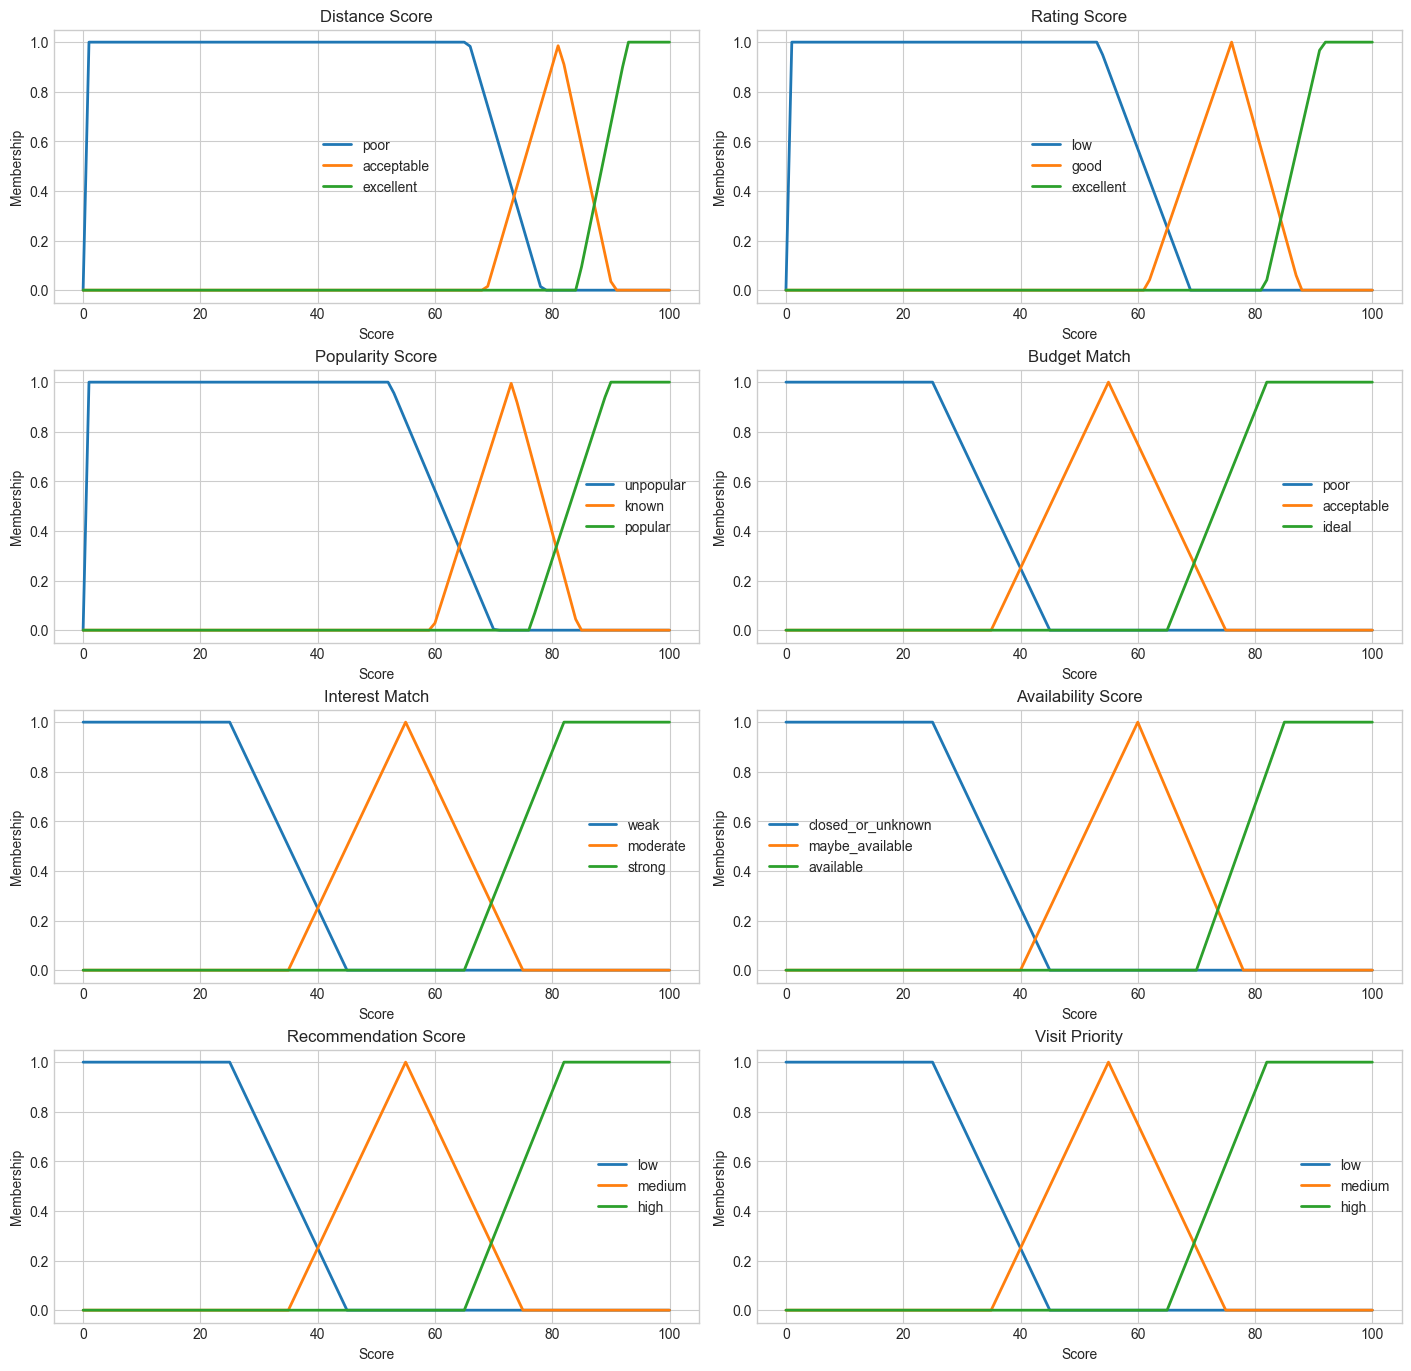

In [9]:
def plot_membership_functions(variables: dict[str, Any], ncols: int = 2) -> None:
    variable_items = list(variables.items())
    nrows = math.ceil(len(variable_items) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.4 * nrows), constrained_layout=True)
    axes = np.array(axes).reshape(-1)

    for ax, (variable_name, variable) in zip(axes, variable_items):
        for term_name, term in variable.terms.items():
            ax.plot(variable.universe, term.mf, linewidth=2, label=term_name)
        ax.set_title(variable_name.replace("_", " ").title())
        ax.set_xlabel("Score")
        ax.set_ylabel("Membership")
        ax.set_ylim(-0.05, 1.05)
        ax.legend(loc="best")

    for ax in axes[len(variable_items):]:
        ax.axis("off")

    plt.show()


plot_membership_functions(fuzzy_variables)

## 10. Run Fuzzy Inference for Each POI

Each POI is evaluated independently by creating a `ControlSystemSimulation`, setting the six fuzzy inputs, computing the Mamdani inference result, and extracting centroid-defuzzified outputs.

In [10]:
FUZZY_INPUT_COLUMNS = [
    "distance_score",
    "rating_score",
    "popularity_score",
    "budget_match",
    "interest_match",
    "availability_score",
]


def evaluate_poi(row: pd.Series, system: ctrl.ControlSystem = fuzzy_system) -> dict[str, float]:
    simulation = ctrl.ControlSystemSimulation(system)

    for column in FUZZY_INPUT_COLUMNS:
        simulation.input[column] = clamp_score(row.get(column), default=50.0)

    try:
        simulation.compute()
        recommendation = float(simulation.output.get("recommendation_score", np.nan))
        priority = float(simulation.output.get("visit_priority", np.nan))
    except Exception:
        recommendation = np.nan
        priority = np.nan

    if not np.isfinite(recommendation):
        recommendation = weighted_fallback_score(row)
    if not np.isfinite(priority):
        priority = (
            0.70 * recommendation
            + 0.20 * clamp_score(row.get("availability_score"), default=60.0)
            + 0.10 * clamp_score(row.get("distance_score"), default=50.0)
        )

    return {
        "recommendation_score": clamp_score(recommendation),
        "visit_priority": clamp_score(priority),
    }


def score_pois_with_fuzzy(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()

    outputs = df.apply(lambda row: pd.Series(evaluate_poi(row)), axis=1)
    scored = pd.concat([df.reset_index(drop=True), outputs.reset_index(drop=True)], axis=1)
    return scored


def rank_pois(scored_df: pd.DataFrame) -> pd.DataFrame:
    if scored_df.empty:
        return scored_df.copy()

    ranked = scored_df.sort_values(
        by=["recommendation_score", "visit_priority", "rating_score", "popularity_score"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)
    ranked.insert(0, "rank", np.arange(1, len(ranked) + 1))
    return ranked


def run_recommendation_pipeline(
    base_df: pd.DataFrame,
    city_name: str,
    user_budget_level: str,
    user_interests: str | list[str] | None,
    preferred_day_index: int,
    preferred_visit_time: int,
    top_n: int = 10,
    hotel_lat: float | None = None,
    hotel_lon: float | None = None,
) -> pd.DataFrame:
    filtered = filter_pois_by_city(base_df, city_name)
    features = add_fuzzy_input_features(
        filtered,
        hotel_lat=hotel_lat,
        hotel_lon=hotel_lon,
        user_budget_level=user_budget_level,
        user_interests=user_interests,
        preferred_day_index=preferred_day_index,
        preferred_visit_time=preferred_visit_time,
    )
    scored = score_pois_with_fuzzy(features)
    ranked = rank_pois(scored)
    return ranked


scored_df = score_pois_with_fuzzy(city_features_df)
ranked_df = rank_pois(scored_df)

print(f"Scored POIs: {len(ranked_df):,}")
display(ranked_df[RANKED_DISPLAY_COLUMNS].head(TOP_N))

Scored POIs: 59


,rank,name,source_type,city,rating,num_reviews,distance_km,rating_score,popularity_score,budget_match,interest_match,availability_score,recommendation_score,visit_priority,category_text
0,1,Sickies Garage Burgers & Brews,restaurant,Las Vegas,4.7,421,6.415137,94.0,74.065876,100.0,52.0,100.0,86.295597,80.695353,Restaurant | Sit down | sit_down | American | 9908 | Bar | 10640 | Vegan options | 10697 | Restaurants | 10591
1,2,Carson Kitchen,restaurant,Las Vegas,4.6,1061,5.516762,92.0,85.373672,100.0,52.0,100.0,86.295597,73.796545,Restaurant | Sit down | sit_down | American | 9908 | Vegetarian friendly | 10665 | Vegan options | 10697 | Gluten fr...
2,3,Omelet House,restaurant,Las Vegas,4.6,887,3.862801,92.0,83.181257,100.0,52.0,100.0,86.295597,73.162446,Restaurant | Sit down | sit_down | American | 9908 | Vegetarian friendly | 10665 | Vegan options | 10697 | Gluten fr...
3,4,Mercato Della Pescheria Las Vegas,restaurant,Las Vegas,4.4,1014,0.477000,88.0,84.819063,100.0,52.0,100.0,85.799265,69.991168,Restaurant | Sit down | sit_down | Italian | 4617 | Seafood | 10643 | Vegetarian friendly | 10665 | Vegan options | ...
4,5,Fountains of Bellagio,attraction,Las Vegas,4.7,92355,1.463035,94.0,100.000000,65.0,52.0,100.0,85.799265,55.000000,Attraction | Sights & Landmarks | 47 | Fountains | 13 | Points of Interest & Landmarks | 163 | none | #1 of 878 thin...
5,6,Mr. Mamas,restaurant,Las Vegas,4.7,2327,6.518970,94.0,94.990043,65.0,52.0,100.0,85.799265,55.000000,Restaurant | Sit down | sit_down | American | 9908 | Vegetarian friendly | 10665 | Vegan options | 10697 | Gluten fr...
6,7,Red Rock Canyon National Conservation Area,attraction,Las Vegas,4.7,26550,22.966677,94.0,89.097009,65.0,52.0,60.0,85.799265,55.000000,Attraction | Nature & Parks | 57 | Nature & Wildlife Areas | 68 | none | #2 of 878 things to do in Las Vegas
7,8,High Roller,attraction,Las Vegas,4.5,26211,0.864458,90.0,88.984618,65.0,52.0,100.0,85.799265,55.000000,Attraction | Sights & Landmarks | 47 | Observation Decks & Towers | 39 | none | #4 of 878 things to do in Las Vegas
8,9,The Las Vegas Strip,attraction,Las Vegas,4.4,35143,1.360033,88.0,91.549353,65.0,52.0,60.0,85.120805,55.000000,Attraction | Sights & Landmarks | 47 | Points of Interest & Landmarks | 163 | Historic Walking Areas | 19 | none | #...
9,10,The Palm - Las Vegas,restaurant,Las Vegas,4.4,1374,0.849625,88.0,88.538467,30.0,52.0,100.0,85.120805,55.000000,Restaurant | Sit down | sit_down | Italian | 4617 | Steakhouse | 10345 | Seafood | 10643 | Vegetarian friendly | 106...


## 11. Visualize Ranked Results

The plots below show the top recommendations and relationships between fuzzy inputs and the final recommendation score.

,rank,name,source_type,city,rating,num_reviews,distance_km,rating_score,popularity_score,budget_match,interest_match,availability_score,recommendation_score,visit_priority,category_text
0,1,Sickies Garage Burgers & Brews,restaurant,Las Vegas,4.7,421,6.42,94.0,74.1,100.0,52.0,100.0,86.3,80.7,Restaurant | Sit down | sit_down | American | 9908 | Bar | 10640 | Vegan options | 10697 | Restaurants | 10591
1,2,Carson Kitchen,restaurant,Las Vegas,4.6,1061,5.52,92.0,85.4,100.0,52.0,100.0,86.3,73.8,Restaurant | Sit down | sit_down | American | 9908 | Vegetarian friendly | 10665 | Vegan options | 10697 | Gluten free options | 10992 | Restaurants | 10591
2,3,Omelet House,restaurant,Las Vegas,4.6,887,3.86,92.0,83.2,100.0,52.0,100.0,86.3,73.2,Restaurant | Sit down | sit_down | American | 9908 | Vegetarian friendly | 10665 | Vegan options | 10697 | Gluten free options | 10992 | Restaurants | 10591
3,4,Mercato Della Pescheria Las Vegas,restaurant,Las Vegas,4.4,1014,0.48,88.0,84.8,100.0,52.0,100.0,85.8,70.0,Restaurant | Sit down | sit_down | Italian | 4617 | Seafood | 10643 | Vegetarian friendly | 10665 | Vegan options | 10697 | Gluten free options | 10992 | Restaurants | 10591
4,5,Fountains of Bellagio,attraction,Las Vegas,4.7,92355,1.46,94.0,100.0,65.0,52.0,100.0,85.8,55.0,Attraction | Sights & Landmarks | 47 | Fountains | 13 | Points of Interest & Landmarks | 163 | none | #1 of 878 things to do in Las Vegas
5,6,Mr. Mamas,restaurant,Las Vegas,4.7,2327,6.52,94.0,95.0,65.0,52.0,100.0,85.8,55.0,Restaurant | Sit down | sit_down | American | 9908 | Vegetarian friendly | 10665 | Vegan options | 10697 | Gluten free options | 10992 | Restaurants | 10591
6,7,Red Rock Canyon National Conservation Area,attraction,Las Vegas,4.7,26550,22.97,94.0,89.1,65.0,52.0,60.0,85.8,55.0,Attraction | Nature & Parks | 57 | Nature & Wildlife Areas | 68 | none | #2 of 878 things to do in Las Vegas
7,8,High Roller,attraction,Las Vegas,4.5,26211,0.86,90.0,89.0,65.0,52.0,100.0,85.8,55.0,Attraction | Sights & Landmarks | 47 | Observation Decks & Towers | 39 | none | #4 of 878 things to do in Las Vegas
8,9,The Las Vegas Strip,attraction,Las Vegas,4.4,35143,1.36,88.0,91.5,65.0,52.0,60.0,85.1,55.0,Attraction | Sights & Landmarks | 47 | Points of Interest & Landmarks | 163 | Historic Walking Areas | 19 | none | #10 of 878 things to do in Las Vegas
9,10,The Palm - Las Vegas,restaurant,Las Vegas,4.4,1374,0.85,88.0,88.5,30.0,52.0,100.0,85.1,55.0,Restaurant | Sit down | sit_down | Italian | 4617 | Steakhouse | 10345 | Seafood | 10643 | Vegetarian friendly | 10665 | Vegan options | 10697 | Gluten free options | 10992 | Restaurants | 10591


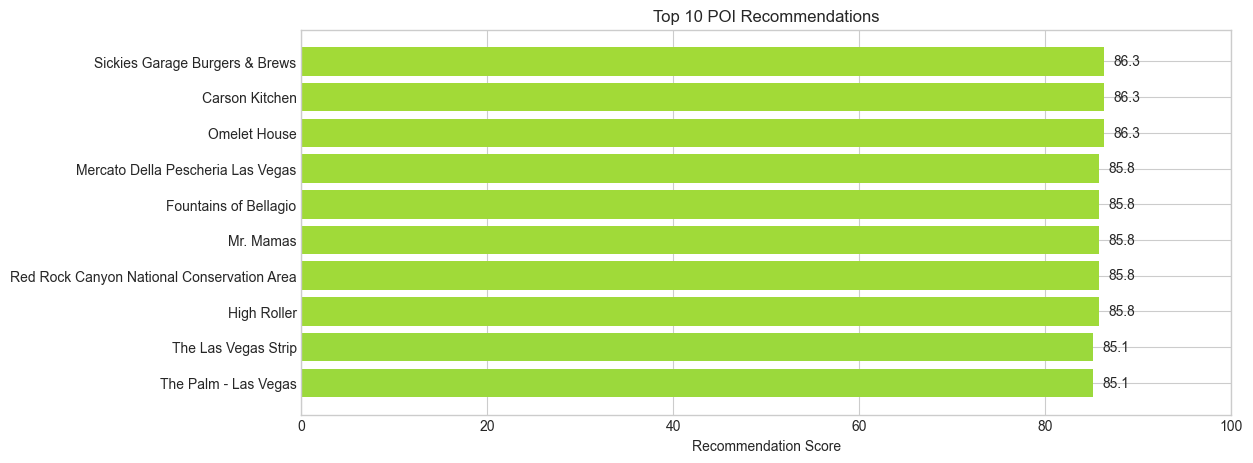

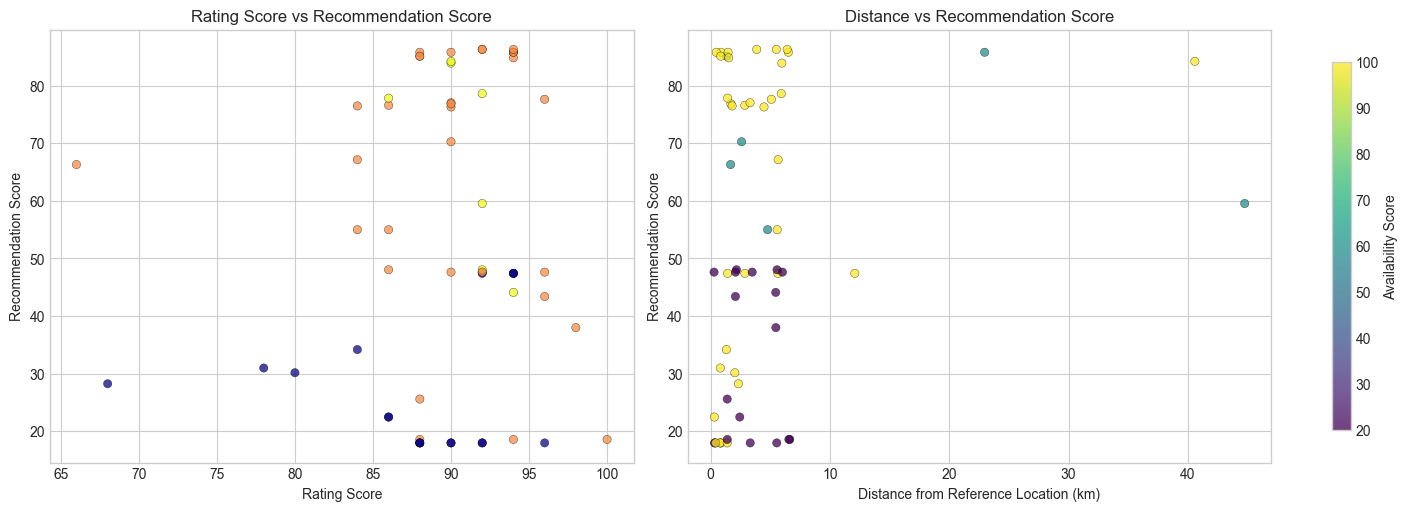

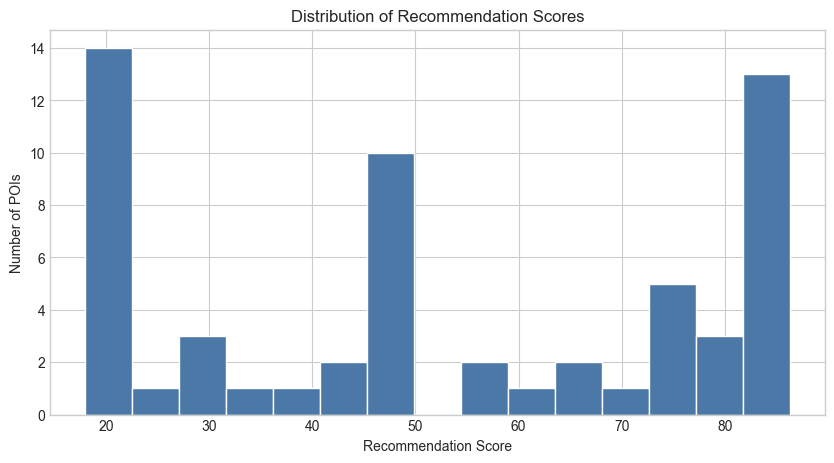

In [11]:
def plot_top_recommendations(ranked: pd.DataFrame, top_n: int = 10) -> None:
    if ranked.empty:
        display(Markdown("No ranked POIs available to plot."))
        return

    top = ranked.head(top_n).iloc[::-1]
    fig_height = max(5, 0.45 * len(top))
    fig, ax = plt.subplots(figsize=(12, fig_height))
    colors = plt.cm.viridis(top["recommendation_score"] / 100)
    ax.barh(top["name"], top["recommendation_score"], color=colors)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Recommendation Score")
    ax.set_title(f"Top {min(top_n, len(ranked))} POI Recommendations")
    for index, score in enumerate(top["recommendation_score"]):
        ax.text(min(score + 1, 99), index, f"{score:.1f}", va="center")
    plt.show()


def plot_scatter_relationships(scored: pd.DataFrame) -> None:
    if scored.empty:
        display(Markdown("No scored POIs available to plot."))
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    axes[0].scatter(
        scored["rating_score"],
        scored["recommendation_score"],
        c=scored["interest_match"],
        cmap="plasma",
        alpha=0.75,
        edgecolor="black",
        linewidth=0.3,
    )
    axes[0].set_xlabel("Rating Score")
    axes[0].set_ylabel("Recommendation Score")
    axes[0].set_title("Rating Score vs Recommendation Score")

    scatter = axes[1].scatter(
        scored["distance_km"],
        scored["recommendation_score"],
        c=scored["availability_score"],
        cmap="viridis",
        alpha=0.75,
        edgecolor="black",
        linewidth=0.3,
    )
    axes[1].set_xlabel("Distance from Reference Location (km)")
    axes[1].set_ylabel("Recommendation Score")
    axes[1].set_title("Distance vs Recommendation Score")

    cbar = fig.colorbar(scatter, ax=axes.ravel().tolist(), shrink=0.85)
    cbar.set_label("Availability Score")
    plt.show()


def plot_score_histogram(scored: pd.DataFrame) -> None:
    if scored.empty:
        display(Markdown("No scored POIs available to plot."))
        return

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(scored["recommendation_score"], bins=15, color="#4C78A8", edgecolor="white")
    ax.set_xlabel("Recommendation Score")
    ax.set_ylabel("Number of POIs")
    ax.set_title("Distribution of Recommendation Scores")
    plt.show()


def style_ranked_table(ranked: pd.DataFrame, top_n: int = 10):
    if ranked.empty:
        return pd.DataFrame()
    display_df = ranked[RANKED_DISPLAY_COLUMNS].head(top_n).copy()
    return (
        display_df.style
        .format(
            {
                "rating": "{:.1f}",
                "distance_km": "{:.2f}",
                "rating_score": "{:.1f}",
                "popularity_score": "{:.1f}",
                "budget_match": "{:.1f}",
                "interest_match": "{:.1f}",
                "availability_score": "{:.1f}",
                "recommendation_score": "{:.1f}",
                "visit_priority": "{:.1f}",
            },
            na_rep="",
        )
        .background_gradient(
            subset=[
                "recommendation_score",
                "visit_priority",
                "rating_score",
                "interest_match",
            ],
            cmap="YlGn",
            vmin=0,
            vmax=100,
        )
    )


display(style_ranked_table(ranked_df, TOP_N))
plot_top_recommendations(ranked_df, TOP_N)
plot_scatter_relationships(scored_df)
plot_score_histogram(scored_df)

## 12. Simple Interactive UI

The widget interface reruns the recommendation pipeline with different city, budget, interest, day/time, hotel location, and top-N settings.

In [12]:
def parse_optional_float_text(text: str) -> float | None:
    text = safe_text(text)
    if not text:
        return None
    return safe_float(text, default=None)


def format_minutes(minute_of_day: int) -> str:
    minute_of_day = safe_int(minute_of_day, default=0) % 1440
    hour = minute_of_day // 60
    minute = minute_of_day % 60
    return f"{hour:02d}:{minute:02d}"


def explain_top_result(row: pd.Series) -> str:
    return (
        f"**Top recommendation:** {row['name']} ({row['source_type']}) scored "
        f"**{row['recommendation_score']:.1f}/100**. "
        f"It has rating score {row['rating_score']:.1f}, interest match {row['interest_match']:.1f}, "
        f"budget match {row['budget_match']:.1f}, availability score {row['availability_score']:.1f}, "
        f"and is {row['distance_km']:.2f} km from the reference location."
    )


def display_interactive_results(
    city_name: str,
    budget_level: str,
    interests_text: str,
    preferred_day: int,
    visit_time: int,
    top_n: int,
    hotel_lat_text: str,
    hotel_lon_text: str,
) -> None:
    ranked = run_recommendation_pipeline(
        base_df=poi_df,
        city_name=city_name,
        user_budget_level=budget_level,
        user_interests=parse_interests(interests_text),
        preferred_day_index=preferred_day,
        preferred_visit_time=visit_time,
        top_n=top_n,
        hotel_lat=parse_optional_float_text(hotel_lat_text),
        hotel_lon=parse_optional_float_text(hotel_lon_text),
    )

    if ranked.empty:
        display(Markdown(f"No POIs found for **{city_name}**. Try a broader city name."))
        return

    day_name = dict((value, label) for label, value in DAY_OPTIONS).get(preferred_day, "Selected day")
    display(Markdown(f"Showing top **{min(top_n, len(ranked))}** POIs for **{city_name}** on **{day_name}** at **{format_minutes(visit_time)}**."))
    display(style_ranked_table(ranked, top_n))
    plot_top_recommendations(ranked, top_n)
    display(Markdown(explain_top_result(ranked.iloc[0])))


if widgets is None:
    display(Markdown("ipywidgets is not available in this environment. Run the non-interactive cells above."))
else:
    city_widget = widgets.Text(value=CITY_NAME, description="City")
    budget_widget = widgets.Dropdown(
        options=list(BUDGET_LEVELS.keys()),
        value=USER_BUDGET_LEVEL if USER_BUDGET_LEVEL in BUDGET_LEVELS else "medium",
        description="Budget",
    )
    interests_widget = widgets.Textarea(
        value=", ".join(USER_INTERESTS),
        description="Interests",
        layout=widgets.Layout(width="680px", height="80px"),
    )
    day_widget = widgets.Dropdown(
        options=DAY_OPTIONS,
        value=PREFERRED_DAY_INDEX,
        description="Day",
    )
    time_widget = widgets.IntSlider(
        value=PREFERRED_VISIT_TIME,
        min=0,
        max=1439,
        step=30,
        description="Time",
        continuous_update=False,
    )
    top_n_widget = widgets.IntSlider(
        value=TOP_N,
        min=3,
        max=30,
        step=1,
        description="Top N",
        continuous_update=False,
    )
    hotel_lat_widget = widgets.Text(
        value="" if HOTEL_LAT is None else str(HOTEL_LAT),
        description="Hotel lat",
        placeholder="blank = estimate center",
    )
    hotel_lon_widget = widgets.Text(
        value="" if HOTEL_LON is None else str(HOTEL_LON),
        description="Hotel lon",
        placeholder="blank = estimate center",
    )

    ui_output = widgets.Output()

    controls = widgets.VBox(
        [
            widgets.HBox([city_widget, budget_widget, day_widget]),
            interests_widget,
            widgets.HBox([time_widget, top_n_widget]),
            widgets.HBox([hotel_lat_widget, hotel_lon_widget]),
        ]
    )

    def on_change(**kwargs):
        with ui_output:
            clear_output(wait=True)
            display_interactive_results(**kwargs)

    interactive_output = widgets.interactive_output(
        on_change,
        {
            "city_name": city_widget,
            "budget_level": budget_widget,
            "interests_text": interests_widget,
            "preferred_day": day_widget,
            "visit_time": time_widget,
            "top_n": top_n_widget,
            "hotel_lat_text": hotel_lat_widget,
            "hotel_lon_text": hotel_lon_widget,
        },
    )

    display(controls, interactive_output, ui_output)

Output()

Output()

## 13. Testing and Validation

The validation section compares the fuzzy system output against simple expert expectations. Labels are assigned as:

- `low`: 0-39
- `medium`: 40-69
- `high`: 70-100

This is not a machine-learning evaluation. It is a sanity check that the rule base behaves in the expected direction.

In [13]:
def label_score(score: float) -> str:
    score = clamp_score(score, default=0.0)
    if score < 40:
        return "low"
    if score < 70:
        return "medium"
    return "high"


def expert_expected_label(row: pd.Series) -> str:
    interest = clamp_score(row.get("interest_match"))
    rating = clamp_score(row.get("rating_score"))
    distance = clamp_score(row.get("distance_score"))
    budget = clamp_score(row.get("budget_match"))
    availability = clamp_score(row.get("availability_score"))
    popularity = clamp_score(row.get("popularity_score"))

    if interest >= 75 and rating >= 75 and availability >= 60 and budget >= 60:
        return "high"
    if interest <= 35 or availability <= 25 or (distance <= 30 and budget <= 45):
        return "low"
    if rating >= 85 and popularity >= 65 and interest >= 55:
        return "high"
    return "medium"


if ranked_df.empty:
    display(Markdown("No real POIs available for manual validation."))
else:
    middle_start = max(len(ranked_df) // 2 - 2, 0)
    validation_sample = pd.concat(
        [
            ranked_df.head(5),
            ranked_df.iloc[middle_start:middle_start + 5],
            ranked_df.tail(5),
        ],
        axis=0,
    ).drop_duplicates(subset=["location_id", "name"]).head(15).copy()

    validation_sample["expected_label"] = validation_sample.apply(expert_expected_label, axis=1)
    validation_sample["predicted_label"] = validation_sample["recommendation_score"].apply(label_score)
    validation_sample["correct"] = validation_sample["expected_label"] == validation_sample["predicted_label"]
    validation_accuracy = validation_sample["correct"].mean()

    display(
        validation_sample[
            [
                "name",
                "expected_label",
                "predicted_label",
                "recommendation_score",
                "correct",
            ]
        ].style.format({"recommendation_score": "{:.1f}"})
    )
    print(f"Manual validation accuracy: {validation_accuracy:.1%}")

,name,expected_label,predicted_label,recommendation_score,correct
0,Sickies Garage Burgers & Brews,medium,high,86.3,False
1,Carson Kitchen,medium,high,86.3,False
2,Omelet House,medium,high,86.3,False
3,Mercato Della Pescheria Las Vegas,medium,high,85.8,False
4,Fountains of Bellagio,medium,high,85.8,False
27,Sid's Cafe,low,medium,48.0,False
28,Andiamo Italian Steakhouse,low,medium,48.0,False
29,Zeppola Cafe Las Vegas,low,medium,47.6,False
30,The Egg & I,low,medium,47.6,False
31,Fresco Italiano,low,medium,47.6,False


Manual validation accuracy: 33.3%


In [14]:
synthetic_cases = pd.DataFrame(
    [
        {
            "name": "Synthetic 1: high rating, high interest, near, available, good budget",
            "distance_score": 95,
            "rating_score": 95,
            "popularity_score": 80,
            "budget_match": 95,
            "interest_match": 95,
            "availability_score": 100,
            "expected_label": "high",
        },
        {
            "name": "Synthetic 2: low interest, far, expensive",
            "distance_score": 10,
            "rating_score": 45,
            "popularity_score": 25,
            "budget_match": 20,
            "interest_match": 15,
            "availability_score": 60,
            "expected_label": "low",
        },
        {
            "name": "Synthetic 3: medium everything",
            "distance_score": 55,
            "rating_score": 70,
            "popularity_score": 55,
            "budget_match": 55,
            "interest_match": 55,
            "availability_score": 60,
            "expected_label": "medium",
        },
        {
            "name": "Synthetic 4: excellent rating but far and expensive",
            "distance_score": 25,
            "rating_score": 95,
            "popularity_score": 70,
            "budget_match": 45,
            "interest_match": 85,
            "availability_score": 60,
            "expected_label": "medium",
        },
        {
            "name": "Synthetic 5: available, nearby restaurant matching cuisine",
            "distance_score": 90,
            "rating_score": 85,
            "popularity_score": 65,
            "budget_match": 90,
            "interest_match": 92,
            "availability_score": 100,
            "expected_label": "high",
        },
    ]
)

synthetic_outputs = synthetic_cases.apply(lambda row: pd.Series(evaluate_poi(row)), axis=1)
synthetic_results = pd.concat([synthetic_cases, synthetic_outputs], axis=1)
synthetic_results["predicted_label"] = synthetic_results["recommendation_score"].apply(label_score)
synthetic_results["correct"] = synthetic_results["expected_label"] == synthetic_results["predicted_label"]
synthetic_accuracy = synthetic_results["correct"].mean()

display(
    synthetic_results[
        [
            "name",
            "expected_label",
            "predicted_label",
            "recommendation_score",
            "visit_priority",
            "correct",
        ]
    ].style.format({"recommendation_score": "{:.1f}", "visit_priority": "{:.1f}"})
)
print(f"Synthetic validation accuracy: {synthetic_accuracy:.1%}")

,name,expected_label,predicted_label,recommendation_score,visit_priority,correct
0,"Synthetic 1: high rating, high interest, near, available, good budget",high,high,86.3,86.3,True
1,"Synthetic 2: low interest, far, expensive",low,low,18.0,18.0,True
2,Synthetic 3: medium everything,medium,medium,55.0,55.0,True
3,Synthetic 4: excellent rating but far and expensive,medium,medium,55.0,55.0,True
4,"Synthetic 5: available, nearby restaurant matching cuisine",high,high,79.3,79.3,True


Synthetic validation accuracy: 100.0%


## 14. Final Project Report Explanation

### Problem Statement

The goal of this project is to recommend points of interest for trip planning by combining attractions and restaurants into a single ranking system. A traveler provides a city, budget level, interests, preferred day/time, and optionally hotel coordinates. The system scores local POIs and returns a ranked list of places to visit.

### Why Fuzzy Logic Is Suitable

POI recommendation is naturally uncertain. A place can be somewhat nearby, fairly popular, moderately expensive, or partially aligned with a user's interests. Fuzzy logic is suitable because it models these gradual concepts using linguistic terms instead of hard thresholds.

### Input Variables

The fuzzy expert system uses six crisp inputs, each scaled from 0 to 100:

- `distance_score`: higher means closer to the hotel or estimated city center.
- `rating_score`: rating converted from 0-5 to 0-100.
- `popularity_score`: log-normalized number of reviews.
- `budget_match`: higher means the POI price level is close to the user's budget.
- `interest_match`: keyword overlap between user interests and POI category/description text.
- `availability_score`: 100 if open at the preferred time, 60 if unknown, and 20 if closed.

### Output Variables

The system produces two outputs:

- `recommendation_score`: overall quality of the recommendation.
- `visit_priority`: how strongly the itinerary should prioritize the POI.

### Membership Functions

Each variable is defined on a 0-100 universe. Inputs use triangular and trapezoidal membership functions such as `low`, `medium`, `high`, or domain-specific terms such as `poor`, `acceptable`, and `excellent`. Outputs use `low`, `medium`, and `high`.

### Rule Base

The rule base contains 14 Mamdani-style expert rules. The rules reward POIs that match user interests, have strong ratings, fit the budget, are available, and are close to the reference location. They penalize weak interest matches, poor budget fit, low ratings, and closed or distant places.

### Inference and Defuzzification

The notebook uses `scikit-fuzzy` control systems for Mamdani inference. The output fuzzy sets are defuzzified using the centroid method, producing crisp 0-100 scores for ranking.

### Testing Methodology

Validation is done in two ways:

- A manual validation sample is selected from the filtered real POIs and compared with simple expert expectations.
- Five synthetic test cases are evaluated to confirm that the rule base behaves correctly for clear high, medium, and low scenarios.

### How to Run the Notebook

1. Update the path and preference configuration near the top if needed.
2. Run all cells from top to bottom.
3. Review the ranked recommendation table and visualizations.
4. Use the widget UI to experiment with different city names, budgets, interests, day/time, and hotel coordinates.

### Limitations and Future Improvements

This system uses local JSON fields only, so recommendation quality depends on data completeness. Interest matching is keyword-based and may miss synonyms. Opening hours can be incomplete or missing. Future work could add richer text matching, traveler profiles, itinerary duration constraints, diversity balancing, neighborhood preferences, and map-based route planning.